In [1]:
import sys
import os
from pathlib import Path

# Get the project root (one level up from /notebooks)
project_root = Path(os.getcwd()).parent

# Add the 'src' directory to the python path
src_path = str(project_root / "src")
if src_path not in sys.path:
    sys.path.append(src_path)

In [2]:
import numpy as np
from scipy.optimize import minimize
from src.mouse_playback_agent import MousePlaybackAgent

In [3]:
def calculate_nll(params, transitions, agent_info_template):
    alpha, gamma, sigma = params # sigma is 'noise/tolerance' parameter

    info = agent_info_template.copy()
    info['step_size'] = alpha
    info['discount'] = gamma
    agent = MousePlaybackAgent()
    agent.agent_init(info)

    total_nll = 0
    trial_count = 0

    # process by trial
    predicted_leave_time = None
    is_tracking_valid_investment = False

    agent.agent_start(transitions[0][0])

    for i in range(len(transitions)):
        obs_t, action, reward, obs_next, terminal = transitions[i]

        in_port_1 = (obs_t[0] == 1.0)
        is_enabled = (obs_t[5] == 0.0)

        # 1. Find the Agent's "Preferred" Leave Time
        # (Look for the first time in the trial where V_leave > V_stay)
        if in_port_1 and is_enabled:
            if not is_tracking_valid_investment:
                is_tracking_valid_investment = True
                predicted_leave_time = None # Reset for this new trial

            if predicted_leave_time is None:
                v_stay = agent.get_value(obs_t)

                obs_leave = obs_t.copy()
                obs_leave[0] = 2.0
                obs_leave[1] = 0.0
                v_leave = agent.get_value(obs_leave)

                if v_leave > v_stay:
                    # The agent wants to leave at this 'time_in_port'
                    predicted_leave_time = obs_t[1]

        # 2. When the trial ends, compare Predicted vs Actual
        if is_tracking_valid_investment and (obs_next[0] != 1.0 or terminal): # Mouse left or session ended
            actual_leave_time = obs_t[1]
            trial_count += 1

            # If agent never wanted to leave, we penalize it (e.g., assume it predicted 'max time')
            if predicted_leave_time is None:
                predicted_leave_time = 20.0 # Or your max trial duration

            # Gaussian NLL (Closeness metric)
            # Constant terms like sqrt(2pi) can be ignored for optimization
            trial_nll = ((actual_leave_time - predicted_leave_time)**2) / (2 * (sigma**2)) + 2 * sigma
            total_nll += trial_nll

            # Reset for next trial
            is_tracking_valid_investment = False
            predicted_leave_time = None

        # Standard Learning Step
        if terminal:
            agent.agent_end(reward)
            if i + 1 < len(transitions):
                agent.agent_start(transitions[i+1][0])
        else:
            agent.agent_step(reward, obs_next)

    print(f"Trying Alpha: {params[0]:.4f}, Gamma: {params[1]:.4f}, Sigma: {params[2]:.3f} | Trial Average NLL: {total_nll/trial_count:.4f}")

    return total_nll / trial_count if trial_count > 0 else total_nll

In [5]:
import pickle
import os
from pathlib import Path

project_root = Path(os.getcwd()).parent
data_folder = project_root / "data"

def load_pooled_transitions(animal_id):
    """
    Loads the giant transition array for a specific animal.
    """
    file_path = data_folder / f"pooled_transitions_{animal_id}.pkl"

    if not file_path.exists():
        raise FileNotFoundError(f"Could not find the data for {animal_id} at {file_path}")

    with open(file_path, 'rb') as f:
        transitions = pickle.load(f)

    print(f"Successfully loaded {len(transitions)} transitions for {animal_id}.")
    return transitions

In [6]:
animal = "SZ036"
all_transitions = load_pooled_transitions(animal)

Successfully loaded 730540 transitions for SZ036.


In [8]:
scales_to_use = [
    -1,  # 0: port
    1 / 2.0,  # 1: time_in_port
    0.0,  # 2: event_timer (SCALE SET TO 0)
    -1,  # 3: context
    0.0,  # 4: rewards_in_context
    -1  # 5: gambling_disabled
]
agent_info = {
    "discount": 0.95,  # Or chosen value
    "step_size": 0.025,  # Start with a smaller step size for stability over large datasets
    "num_tilings": 16,
    "iht_size": 32768,
    "gambling_max_time_s": 30.0,  # Match data_loader params if used
    "context_rewards_max": 4,  # Match data_loader params if used
    "scales": scales_to_use
}  # agent parameters

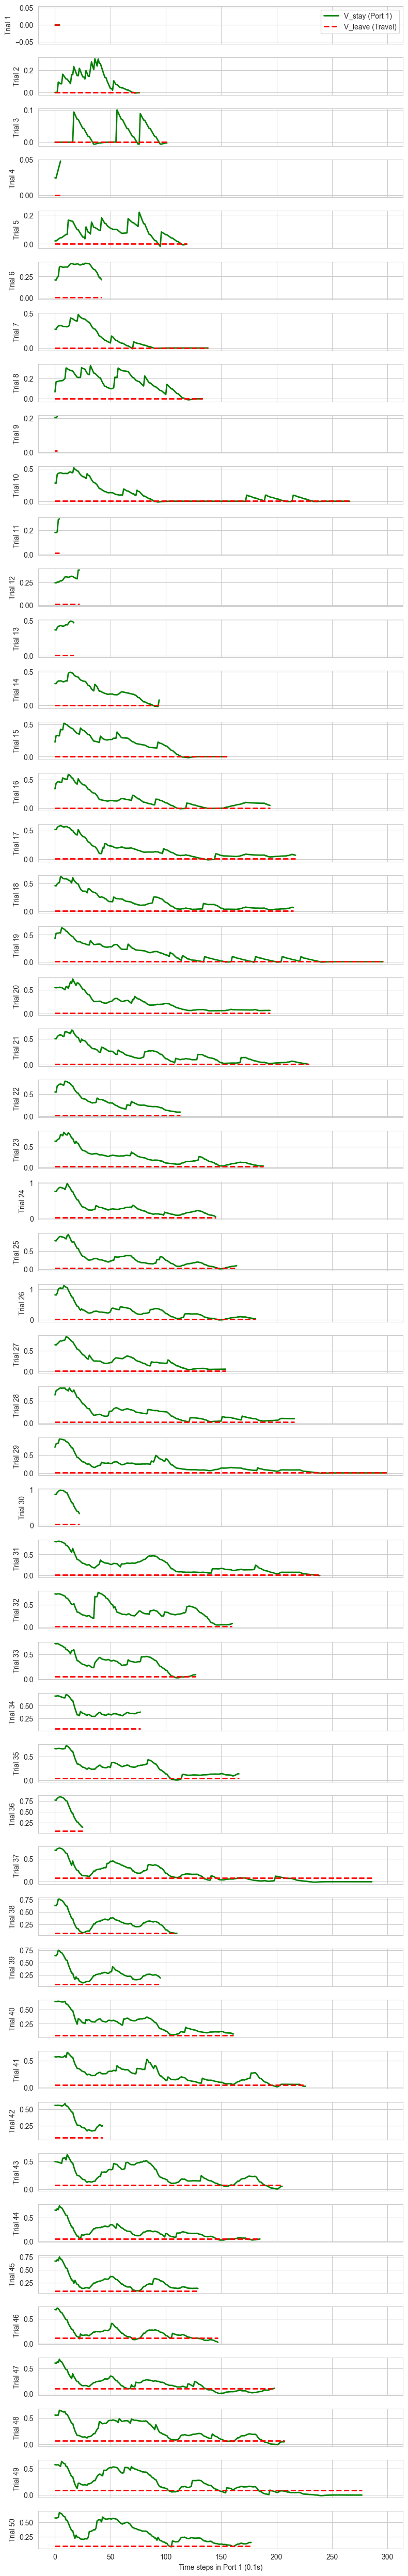

In [9]:
import matplotlib.pyplot as plt
import numpy as np

def diagnose_values(transitions, agent_info_template, num_trials=50):
    # Use high alpha/gamma to ensure we see learning dynamics clearly
    info = agent_info_template.copy()
    info['step_size'] = 0.1
    info['discount'] = 0.9

    agent = MousePlaybackAgent()
    agent.agent_init(info)

    trials_data = [] # List of dicts: {'stay': [], 'leave': []}
    current_trial_stay = []
    current_trial_leave = []

    agent.agent_start(transitions[0][0])

    for i in range(len(transitions)):
        if len(trials_data) >= num_trials:
            break

        obs_t, _, reward, obs_next, terminal = transitions[i]

        # FEATURE INDEXING:
        # obs[0] = Port, obs[5] = Gambling Disabled (1.0 = Disabled, 0.0 = Enabled)

        in_port_1 = (obs_t[0] == 1.0)
        is_enabled = (obs_t[5] == 0.0)

        # 1. If in Port 1, record the decision values
        if in_port_1 and is_enabled:
            v_s = agent.get_value(obs_t)

            # Synthetic 'Leave' observation for Port 2
            obs_l = obs_t.copy()
            obs_l[0] = 2.0; obs_l[1] = 0.0
            v_l = agent.get_value(obs_l)

            current_trial_stay.append(v_s)
            current_trial_leave.append(v_l)

            # 2. If the mouse leaves Port 1 in the next step, close this trial
            if obs_next[0] != 1.0:
                if len(current_trial_stay) > 0:
                    trials_data.append({
                        'stay': current_trial_stay,
                        'leave': current_trial_leave
                    })
                    current_trial_stay = []
                    current_trial_leave = []

        # 3. Step the agent (always, so it learns from rewards)
        if terminal:
            agent.agent_end(reward)
            if i + 1 < len(transitions):
                agent.agent_start(transitions[i+1][0])
        else:
            agent.agent_step(reward, obs_next)

    # --- PLOTTING ---
    fig, axes = plt.subplots(num_trials, 1, figsize=(8, 1 * num_trials), sharex=True)
    if num_trials == 1: axes = [axes] # Handle single subplot case

    for idx, data in enumerate(trials_data):
        axes[idx].plot(data['stay'], label="V_stay (Port 1)", color='green', linewidth=2)
        axes[idx].plot(data['leave'], label="V_leave (Travel)", color='red', linestyle='--', linewidth=2)
        axes[idx].set_ylabel(f"Trial {idx+1}")
        if idx == 0:
            axes[idx].legend(loc='upper right')

    plt.xlabel("Time steps in Port 1 (0.1s)")
    plt.tight_layout()
    plt.show()

# Run the diagnosis
diagnose_values(all_transitions, agent_info)

In [11]:
import pandas as pd
# Grid search that uses a FIXED sigma
# 1. Define the Grid
alphas = np.arange(0.001, 0.015, 0.004)
gammas = np.arange(0.85, 0.99, 0.04)
# sigmas = np.arange(2.9, 3.4, 0.1)
sigmas = [2.8, 3.0, 3.2, 3.4]

grid_results = []

print("Starting Grid Search...")
for a in alphas:
    for g in gammas:
        for s in sigmas:
            # Calculate NLL for this specific pair
            nll = calculate_nll([a, g, s], all_transitions, agent_info)

            print(f"Alpha: {a:.3f}, Gamma: {g:.3f}, Sigma: {s:3f} | Avg NLL: {nll:.4f}")
            grid_results.append({'alpha': a, 'gamma': g, 'sigma': s, 'nll': nll})

# 2. Find the best pair
grid_df = pd.DataFrame(grid_results)
best_row = grid_df.loc[grid_df['nll'].idxmin()]

print("\n--- GRID SEARCH COMPLETE ---")
print(f"Best Alpha: {best_row['alpha']}")
print(f"Best Gamma: {best_row['gamma']}")
print(f"Best Sigma: {best_row['sigma']}")
print(f"Lowest NLL: {best_row['nll']}")

Starting Grid Search...
Trying Alpha: 0.0010, Gamma: 0.8500, Sigma: 2.800 | Trial Average NLL: 13.9297
Alpha: 0.001, Gamma: 0.850, Sigma: 2.800000 | Avg NLL: 13.9297
Trying Alpha: 0.0010, Gamma: 0.8500, Sigma: 3.000 | Trial Average NLL: 13.2561
Alpha: 0.001, Gamma: 0.850, Sigma: 3.000000 | Avg NLL: 13.2561
Trying Alpha: 0.0010, Gamma: 0.8500, Sigma: 3.200 | Trial Average NLL: 12.7774
Alpha: 0.001, Gamma: 0.850, Sigma: 3.200000 | Avg NLL: 12.7774
Trying Alpha: 0.0010, Gamma: 0.8500, Sigma: 3.400 | Trial Average NLL: 12.4492
Alpha: 0.001, Gamma: 0.850, Sigma: 3.400000 | Avg NLL: 12.4492
Trying Alpha: 0.0010, Gamma: 0.8900, Sigma: 2.800 | Trial Average NLL: 13.7124
Alpha: 0.001, Gamma: 0.890, Sigma: 2.800000 | Avg NLL: 13.7124
Trying Alpha: 0.0010, Gamma: 0.8900, Sigma: 3.000 | Trial Average NLL: 13.0668
Alpha: 0.001, Gamma: 0.890, Sigma: 3.000000 | Avg NLL: 13.0668
Trying Alpha: 0.0010, Gamma: 0.8900, Sigma: 3.200 | Trial Average NLL: 12.6111
Alpha: 0.001, Gamma: 0.890, Sigma: 3.200000 |

In [ ]:
import pandas as pd
import json
from pathlib import Path
import os

def save_grid_results(results, filename_base, folder_name="model_fitting_midsteps", state_config="uniform_tile_contexted"):
    """
    Saves grid search results to both CSV and JSON formats.
    """
    # 1. Create the results directory if it doesn't exist
    # This goes up one level from /notebooks to the root, then into /results
    project_root = Path(os.getcwd()).parent
    save_path = project_root / folder_name / state_config
    save_path.mkdir(parents=True, exist_ok=True)

    # 2. Convert to DataFrame for CSV saving
    df = pd.DataFrame(results)
    csv_file = save_path / f"{filename_base}.csv"
    df.to_csv(csv_file, index=False)

    # 3. Save as JSON for easy reloading in Python later
    json_file = save_path / f"{filename_base}.json"
    with open(json_file, 'w') as f:
        json.dump(results, f, indent=4)

    print(f"✅ Results saved successfully!")
    print(f"CSV: {csv_file}")
    print(f"JSON: {json_file}")

# --- Example Usage ---
animal_id = "SZ036"
save_grid_results(grid_results, f"parameter_grid_search_results_{animal_id}", folder_name="model_fitting_midsteps", state_config="uniform_tile_contexted")

In [ ]:
import seaborn as sns

def plot_nll_response_surface(grid_results):
    df = pd.DataFrame(grid_results)

    # Pivot the data
    pivot_table = df[df['sigma'] == 3.1].pivot(index='alpha', columns='gamma', values='nll')

    plt.figure(figsize=(10, 8))

    # Corrected heatmap call
    ax = sns.heatmap(pivot_table,
                     annot=True,
                     fmt=".2f",
                     cmap="YlGnBu",
                     cbar_kws={'label': 'Average NLL per Trial'})

    # Optional: If you want to see the Alpha axis more clearly,
    # you can format the labels to show scientific notation
    ax.set_yticklabels([f"{float(t.get_text()):.3f}" for t in ax.get_yticklabels()])

    plt.title("NLL Response Surface: Finding Optimal RL Parameters", fontsize=14, pad=20)
    plt.xlabel("Discount Factor (γ)", fontsize=12)
    plt.ylabel("Learning Rate (α)", fontsize=12)

    # Find the absolute best to mark it
    best_nll = df['nll'].min()
    best_params = df.loc[df['nll'] == best_nll].iloc[0]

    print(f"Visualizing surface... Best point is Alpha: {best_params['alpha']}, Gamma: {best_params['gamma']}")

    plt.tight_layout()
    plt.show()

plot_nll_response_surface(grid_results)

In [ ]:
import scipy.stats as stats

def generate_leave_decision_comparison(params, transitions, agent_info_template):
    alpha, gamma, _ = params

    info = agent_info_template.copy()
    info['step_size'] = alpha
    info['discount'] = gamma
    agent = MousePlaybackAgent()
    agent.agent_init(info)

    predicted_latencies = []
    actual_latencies = []

    is_tracking = False
    predicted_time = None

    agent.agent_start(transitions[0][0])

    for i in range(len(transitions)):
        obs_t, _, _, obs_next, terminal = transitions[i]

        # Check if Gambling/Investment Port (1) is Enabled (obs[5] == 0)
        in_port_1 = (obs_t[0] == 1.0)
        is_enabled = (obs_t[5] == 0.0)

        if in_port_1 and is_enabled:
            if not is_tracking:
                is_tracking = True
                predicted_time = None

            # Find the first moment the agent wants to leave
            if predicted_time is None:
                v_stay = agent.get_value(obs_t)
                obs_l = obs_t.copy()
                obs_l[0] = 2.0; obs_l[1] = 0.0 # Travel Port state
                v_leave = agent.get_value(obs_l)

                if v_leave > v_stay:
                    predicted_time = obs_t[1] # Time in port at crossover

        # End of the valid investment phase
        if is_tracking and (obs_next[0] != 1.0 or terminal):
            actual_time = obs_t[1]

            # If agent never predicted a leave, cap at 20s
            pred_val = predicted_time if predicted_time is not None else 20.0

            predicted_latencies.append(pred_val)
            actual_latencies.append(actual_time)
            is_tracking = False

        # Learn from the outcome
        if terminal:
            agent.agent_end(transitions[i][2])
            if i + 1 < len(transitions):
                agent.agent_start(transitions[i+1][0])
        else:
            agent.agent_step(transitions[i][2], obs_next)

    return np.array(predicted_latencies), np.array(actual_latencies)

# 1. Run the comparison
best_params = [0.004, 0.94, 1.0] # Use your grid search winners
pred, actual = generate_leave_decision_comparison(best_params, all_transitions, agent_info)

# 2. Plotting
plt.figure(figsize=(8, 8))
plt.scatter(actual, pred, alpha=0.5, color='teal', label='Trials')

# Add Unity Line (y=x)
lims = [0, 30]
plt.plot(lims, lims, 'r--', alpha=0.75, zorder=0, label='Perfect Prediction')

# Statistics
slope, intercept, r_value, p_value, std_err = stats.linregress(actual, pred)
plt.text(1, max(pred)-2, f'$R^2 = {r_value**2:.3f}$\n$p = {p_value:.2e}$',
         bbox=dict(facecolor='white', alpha=0.5))

plt.title("Model Validation: Predicted vs. Actual Stay Times (Port 1)")
plt.xlabel("Actual Mouse Stay Time (s)")
plt.ylabel("Agent Predicted Stay Time (s)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# 1. Use the best results from the grid as the starting point
initial_guess = [0.01, 0.9, 1]

# 2. Re-include Sigma in the bounds so the model can fine-tune its 'noise'
bounds = [(0.007, 0.013), (0.8, 0.99), (1, 1)]

print("Refining parameters for maximum precision...")
result = minimize(
    calculate_nll,
    initial_guess,
    args=(all_transitions, agent_info),
    bounds=bounds,
    method='L-BFGS-B'
)

final_alpha, final_gamma, final_sigma = result.x
print(f"\n--- FINAL PARAMETERS FOUND ---")
print(f"Alpha: {final_alpha:.5f}")
print(f"Gamma: {final_gamma:.5f}")
print(f"Sigma: {final_sigma:.5f}")
print(f"Final NLL: {result.fun:.4f}")

In [ ]:
# Define bounds: alpha [0,1], gamma [0.5,1], sigma [0.1, 5.0]
bounds = [(0.0001, 1.0), (0.5, 1), (0.1, 5)]
initial_guess = [0.001, 0.9, 1]
# This will find the parameters that make 'nll' as small as possible
scales_to_use = [
    -1,  # 0: port
    1 / 2.0,  # 1: time_in_port
    0.0,  # 2: event_timer (SCALE SET TO 0)
    -1,  # 3: context
    0.0,  # 4: rewards_in_context
    -1  # 5: gambling_disabled
]
agent_info = {
    "discount": 0.95,  # Or chosen value
    "step_size": 0.025,  # Start with a smaller step size for stability over large datasets
    "num_tilings": 16,
    "iht_size": 32768,
    "gambling_max_time_s": 30.0,  # Match data_loader params if used
    "context_rewards_max": 4,  # Match data_loader params if used
    "scales": scales_to_use
}  # agent parameters
result = minimize(calculate_nll, initial_guess, args=(all_transitions, agent_info), bounds=bounds, method='L-BFGS-B')

print(f"Best Parameters: Alpha={result.x[0]:.4f}, Gamma={result.x[1]:.4f}, Sigma={result.x[2]:.3f}")

In [ ]:
# bounds for alpha, gamma, and beta
bounds = [(0.0001, 1), (0.2, 1), (0.1, 20)]
starts = [
    [0.001, 0.4, 19],
    [0.001, 0.6, 14],
    [0.001, 0.8, 9],
    [0.001, 0.99, 4]
]
best_overall_result = None
lowest_nll = np.inf
for start_guess in starts:
    print(f"\n--- Starting Optimization from {start_guess} ---")
    res = minimize(calculate_nll, start_guess, args=(all_transitions, agent_info),
                   bounds=bounds, method='L-BFGS-B')

    if res.fun < lowest_nll:
        lowest_nll = res.fun
        best_overall_result = res
        print(f"New Best Found! NLL: {lowest_nll:.2f}")

print(f"Global Best Params: {best_overall_result.x}")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from src.mouse_playback_agent import MousePlaybackAgent

def run_sensitivity_test(transitions, agent_info, costs_to_test):
    results = []

    # We use stable alpha/gamma for the test
    test_params = [0.005, 0.94]

    for cost in tqdm(costs_to_test, desc="Testing Opportunity Costs"):
        # Reset Agent
        agent = MousePlaybackAgent()
        agent.agent_init(agent_info)
        agent.step_size = test_params[0]
        agent.discount = test_params[1]

        predicted_times = []
        agent.agent_start(transitions[0][0])

        is_tracking = False
        pred_t = None

        for i in range(len(transitions)):
            obs_t, _, reward, obs_next, terminal = transitions[i]

            # 1. Decision Logic with Cost
            if obs_t[0] == 1.0 and obs_t[5] == 0.0:
                if not is_tracking:
                    is_tracking, pred_t = True, None

                if pred_t is None:
                    v_stay = agent.get_value(obs_t)
                    obs_l = obs_t.copy(); obs_l[0] = 2.0; obs_l[1] = 0.0
                    # Applying the test cost
                    v_leave = agent.get_value(obs_l) + cost

                    if v_leave > v_stay:
                        pred_t = obs_t[1]

            # 2. End of trial capture
            if is_tracking and (obs_next[0] != 1.0 or terminal):
                predicted_times.append(pred_t if pred_t is not None else 20.0)
                is_tracking = False

            # 3. Learning
            if terminal:
                agent.agent_end(reward)
                if i+1 < len(transitions): agent.agent_start(transitions[i+1][0])
            else:
                agent.agent_step(reward, obs_next)

        avg_pred = np.mean(predicted_times)
        results.append({'cost': cost, 'avg_leave_time': avg_pred})

    return results

# --- RUN TEST ---
animal_id = 'RK007'
all_transitions = load_pooled_transitions(animal_id)
scales_to_use = [-1, 1 / 2.0, 0.0, -1, 0.0, -1]

agent_info = {
    "discount": 0.95,
    "step_size": 0.025,
    "num_tilings": 16,
    "iht_size": 16384,  # Set to 'Goldilocks' size to avoid collisions and mem-leak
    "gambling_max_time_s": 30.0,
    "context_rewards_max": 4,
    "scales": scales_to_use
}

# 1. First, find out what the maximum V_stay is in your data
# This helps us pick a better range for opportunity_cost
test_agent = MousePlaybackAgent()
test_agent.agent_init(agent_info)

# --- CORRECTED WARMUP LOOP ---
# Initialize the very first state
test_agent.agent_start(all_transitions[0][0])

# Loop through the first 2000 steps
for i in range(len(all_transitions[:2000])):
    obs, act, rew, obs_next, term = all_transitions[i]

    if term:
        test_agent.agent_end(rew)
        # After a trial ends, we must start the next one if data is available
        if i + 1 < 2000:
            test_agent.agent_start(all_transitions[i+1][0])
    else:
        # Now self.last_state_tiles is guaranteed to exist
        test_agent.agent_step(rew, obs_next)

max_v = np.max(test_agent.w)
print(f"Max weight value after warmup: {max_v}")

# 2. Run sensitivity with a much smaller, logarithmic range
# If max_v is small, 0.5 was way too much cost.
test_costs = np.logspace(-4, -1, 10) # Testing 0.0001 to 0.1

test_results = run_sensitivity_test(all_transitions, agent_info, test_costs)

# --- ACTUAL BEHAVIOR ---
actual_latencies = []
is_tracking = False

for i in range(len(all_transitions)):
    obs_t, _, _, obs_next, terminal = all_transitions[i]

    # Identify the 'Investment' phase (Port 1 and Enabled)
    in_port_1 = (obs_t[0] == 1.0)
    is_enabled = (obs_t[5] == 0.0)

    if in_port_1 and is_enabled:
        is_tracking = True

    # Capture the final 'time_in_port' when the mouse leaves
    if is_tracking and (obs_next[0] != 1.0 or terminal):
        actual_latencies.append(obs_t[1])
        is_tracking = False

print(f"Mean mouse stay time: {np.mean(actual_latencies):.2f}s")

# --- PLOT RESULTS ---
costs_x = [r['cost'] for r in test_results]
times_y = [r['avg_leave_time'] for r in test_results]

plt.figure(figsize=(8, 5))
plt.plot(costs_x, times_y, marker='o', color='royalblue')
plt.axhline(y=np.mean(actual_latencies), color='r', linestyle='--', label='Mouse Actual Average')
plt.xlabel("Opportunity Cost Offset")
plt.ylabel("Avg Predicted Leave Time (s)")
plt.title("Calibration: Finding the Right 'Incentive' to Leave")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()